# Health&Life Analytics — Café, Sono e Saúde
### Análise Exploratória, Visualização de Insights e Modelo Preditivo

**Dataset:** `synthetic_coffee_health_10000.csv` (10.000 registros sintéticos fornecidos pela empresa)
**Objetivo:** entender o perfil dos clientes, investigar a relação entre consumo de café e aspectos de saúde (sono, estresse, atividade física) e construir um modelo preditivo para `Sleep_Quality`.

---
## PARTE 1 — Análise Exploratória de Dados (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


### 1.1 Carregando o dataset

In [2]:
caminho_csv = "synthetic_coffee_health_10000.csv"
df = pd.read_csv(caminho_csv)
print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Dimensões do dataset: 10000 linhas x 16 colunas


In [3]:
print("Colunas e tipos de dados:\n")
df.dtypes


Colunas e tipos de dados:



### 1.2 Nulos e duplicados

In [4]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
tabela_nulos = pd.DataFrame({"qtd_nulos": nulos, "pct_nulos": pct_nulos})
tabela_nulos = tabela_nulos[tabela_nulos["qtd_nulos"] > 0].sort_values("qtd_nulos", ascending=False)
print("Colunas com valores nulos:")
print(tabela_nulos if len(tabela_nulos) else "Nenhuma coluna com nulos.")

duplicadas = df.duplicated().sum()
print(f"\nLinhas 100% duplicadas: {duplicadas}")


Colunas com valores nulos:
               qtd_nulos  pct_nulos
Health_Issues       5941      59.41

Linhas 100% duplicadas: 0


**Interpretação dos nulos:** os únicos nulos estão em `Health_Issues` (~59% das linhas). Olhando os valores não-nulos (`Mild`, `Moderate`, `Severe`), fica claro que o `NaN` aqui **não é um dado faltante no sentido tradicional** — é o cliente **não reportar nenhum problema de saúde**. Por isso, em vez de imputar pela moda ou descartar linhas, vamos preencher explicitamente com a categoria `"None"`.

**Duplicados:** não há linhas 100% duplicadas — não é necessário nenhum tratamento de remoção.


In [5]:
df["Health_Issues"] = df["Health_Issues"].fillna("None")

print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"Duplicadas: {df.duplicated().sum()}")
print(f"\nDimensões finais após tratamento: {df.shape}")


Nulos restantes: 0
Duplicadas: 0

Dimensões finais após tratamento: (10000, 16)


### 1.3 Estatísticas descritivas

In [6]:
colunas_numericas = ["Age","Coffee_Intake","Caffeine_mg","Sleep_Hours","BMI","Heart_Rate","Physical_Activity_Hours"]
colunas_categoricas = ["Gender","Country","Sleep_Quality","Stress_Level","Health_Issues","Occupation"]
colunas_binarias = ["Smoking","Alcohol_Consumption"]

df[colunas_numericas].describe().T


In [7]:
df[colunas_categoricas + colunas_binarias].describe().T


---
## 2. Explorando as variáveis numéricas


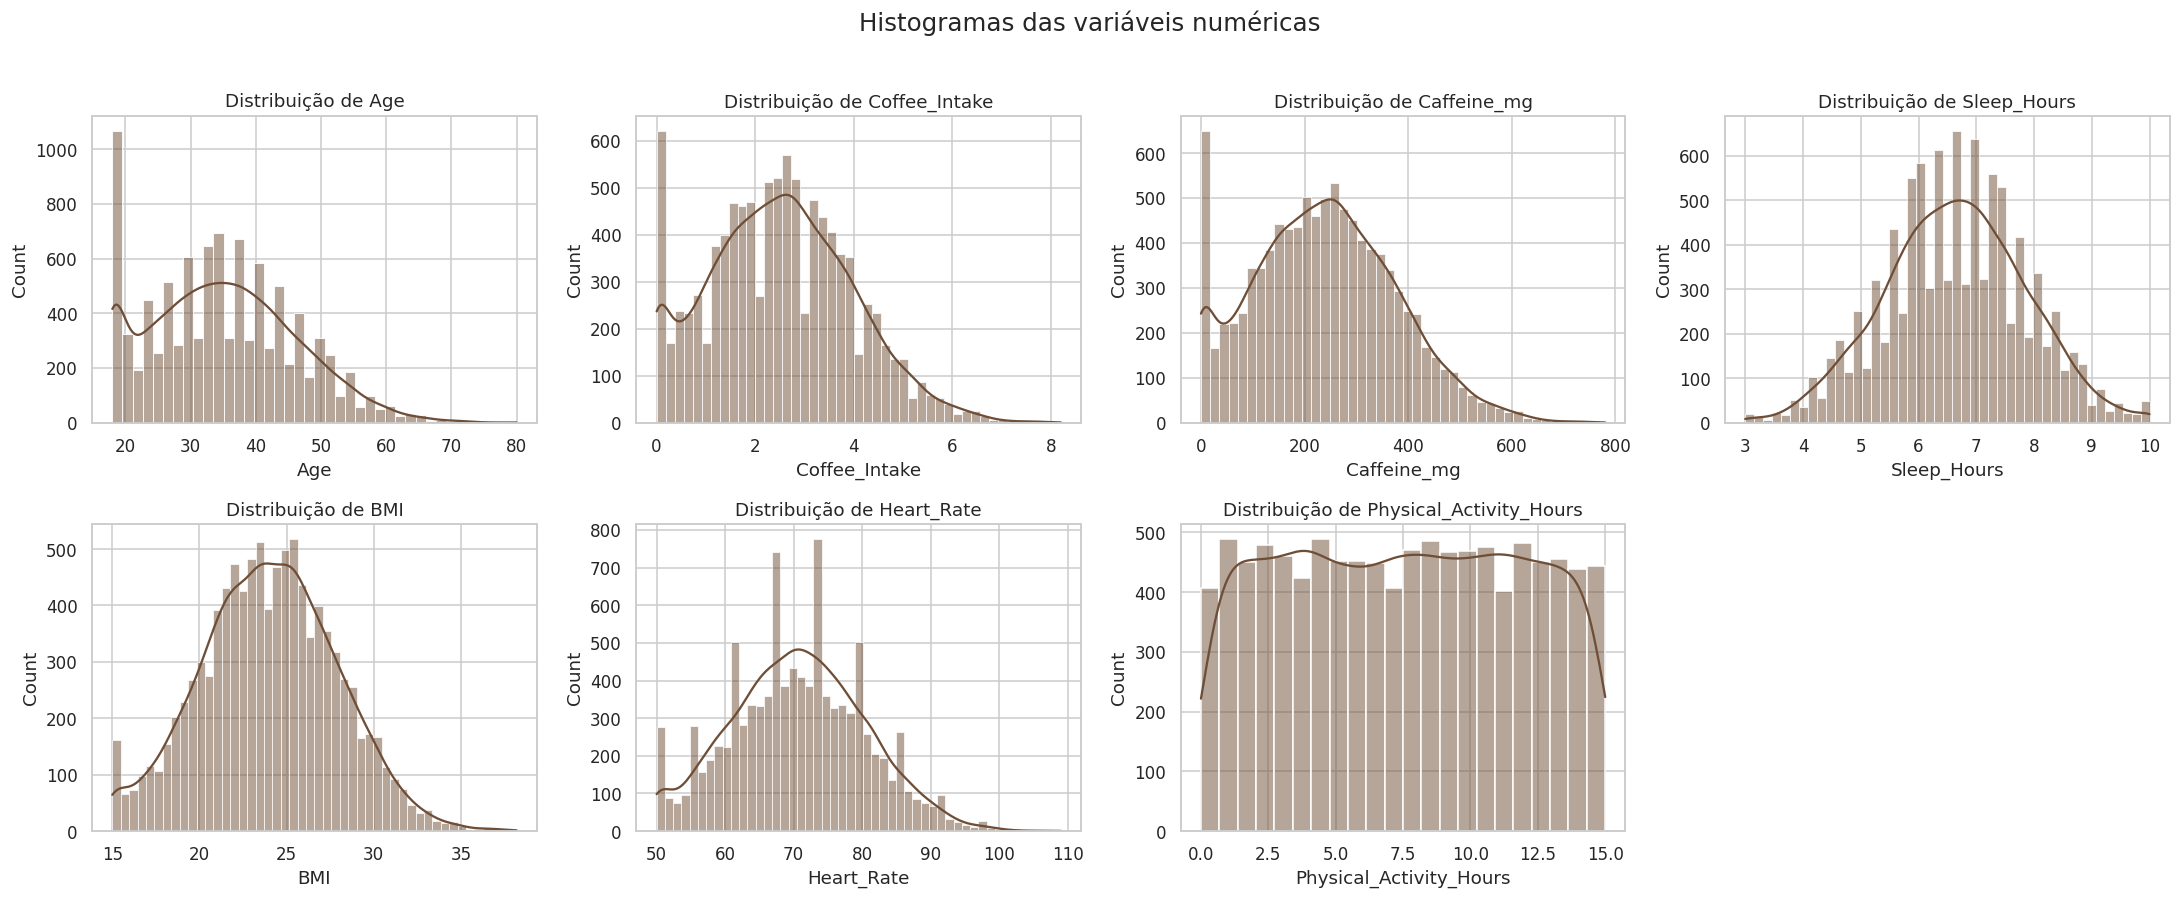

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for ax, col in zip(axes, colunas_numericas):
    sns.histplot(df[col], kde=True, ax=ax, color="#6f4e37")
    ax.set_title(f"Distribuição de {col}")
axes[-1].axis("off")
fig.suptitle("Histogramas das variáveis numéricas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


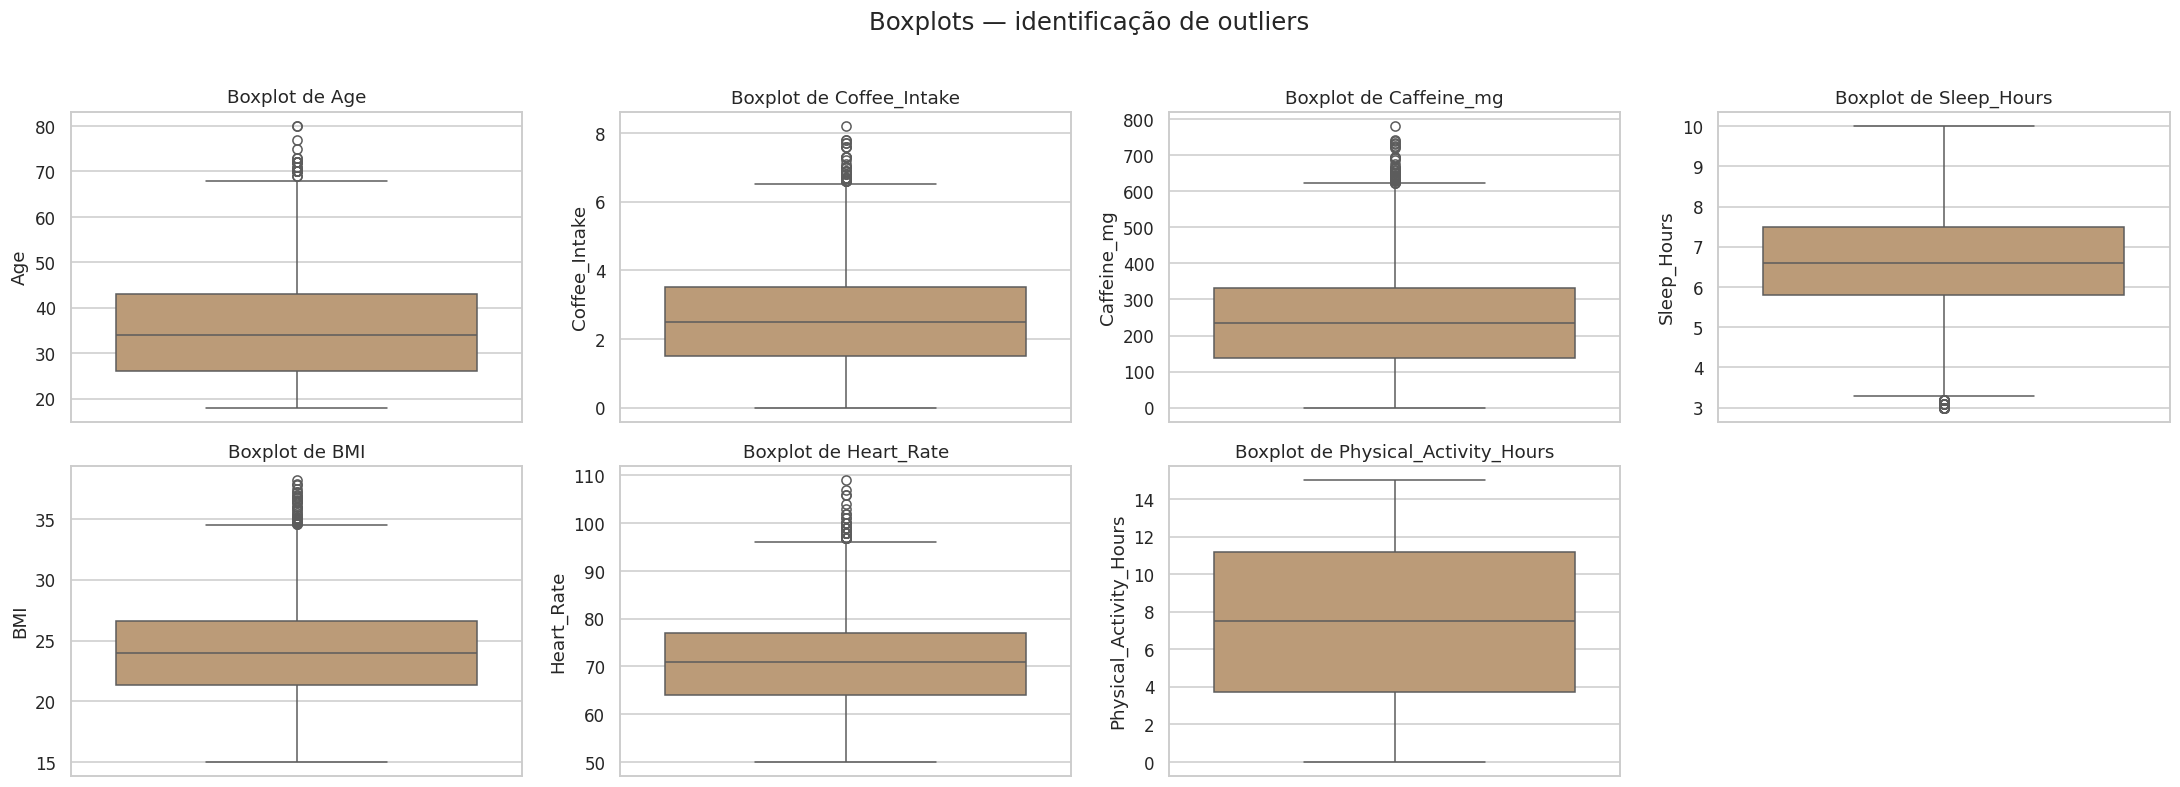

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
axes = axes.flatten()
for ax, col in zip(axes, colunas_numericas):
    sns.boxplot(y=df[col], ax=ax, color="#c69c6d")
    ax.set_title(f"Boxplot de {col}")
axes[-1].axis("off")
fig.suptitle("Boxplots — identificação de outliers", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**Leitura rápida:** `Age`, `Sleep_Hours`, `BMI` e `Heart_Rate` têm distribuições aproximadamente simétricas e sem outliers extremos. `Coffee_Intake` e `Caffeine_mg` (que refletem a mesma dose de consumo) concentram a maioria dos clientes entre 1–4 xícaras/dia, com uma cauda de consumidores pesados (>6 xícaras/dia).


---
## 3. Explorando as variáveis categóricas


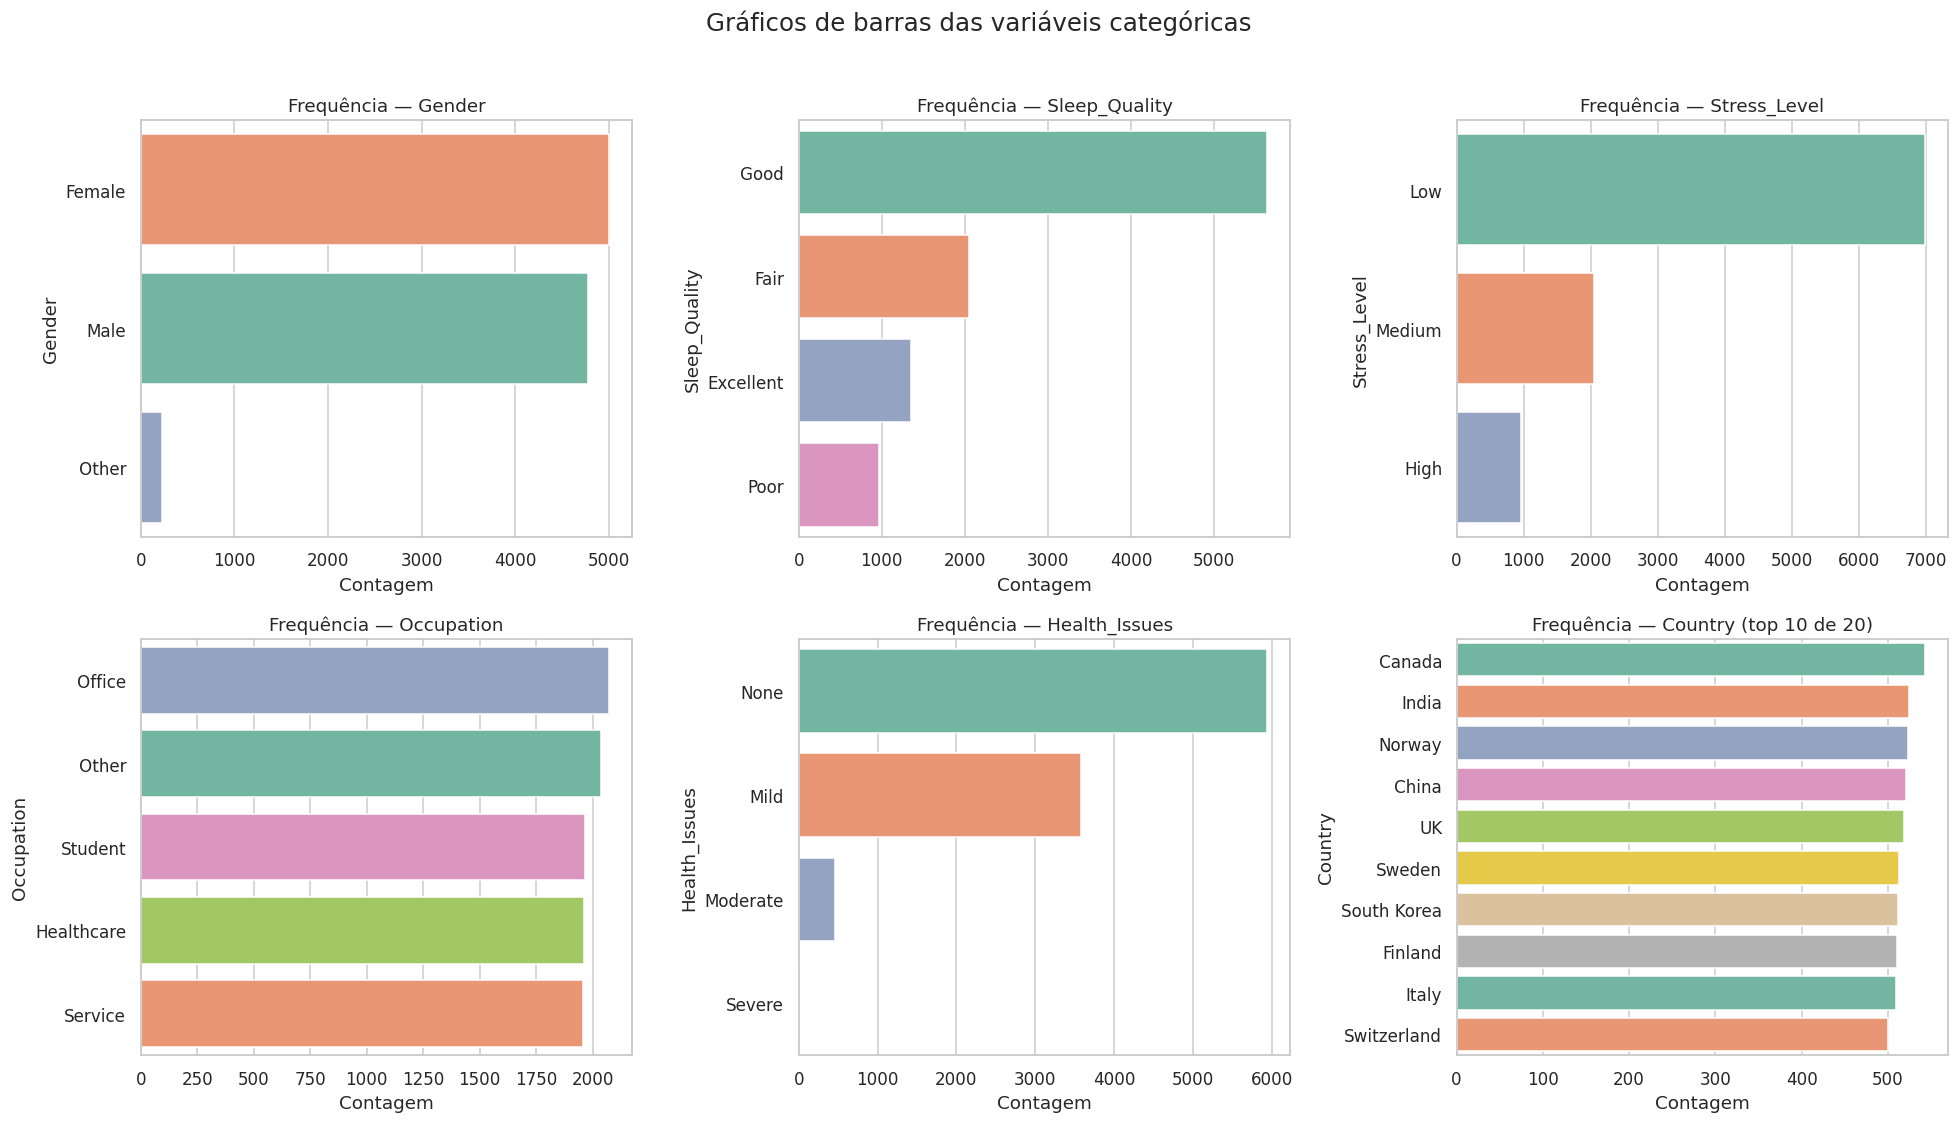

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, ["Gender","Sleep_Quality","Stress_Level","Occupation","Health_Issues"]):
    ordem = df[col].value_counts().index
    sns.countplot(y=df[col], order=ordem, ax=ax, hue=df[col], legend=False, palette="Set2")
    ax.set_title(f"Frequência — {col}")
    ax.set_xlabel("Contagem")

top_countries = df["Country"].value_counts().head(10)
sns.barplot(y=top_countries.index, x=top_countries.values, ax=axes[5], hue=top_countries.index, legend=False, palette="Set2")
axes[5].set_title("Frequência — Country (top 10 de 20)")
axes[5].set_xlabel("Contagem")

fig.suptitle("Gráficos de barras das variáveis categóricas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


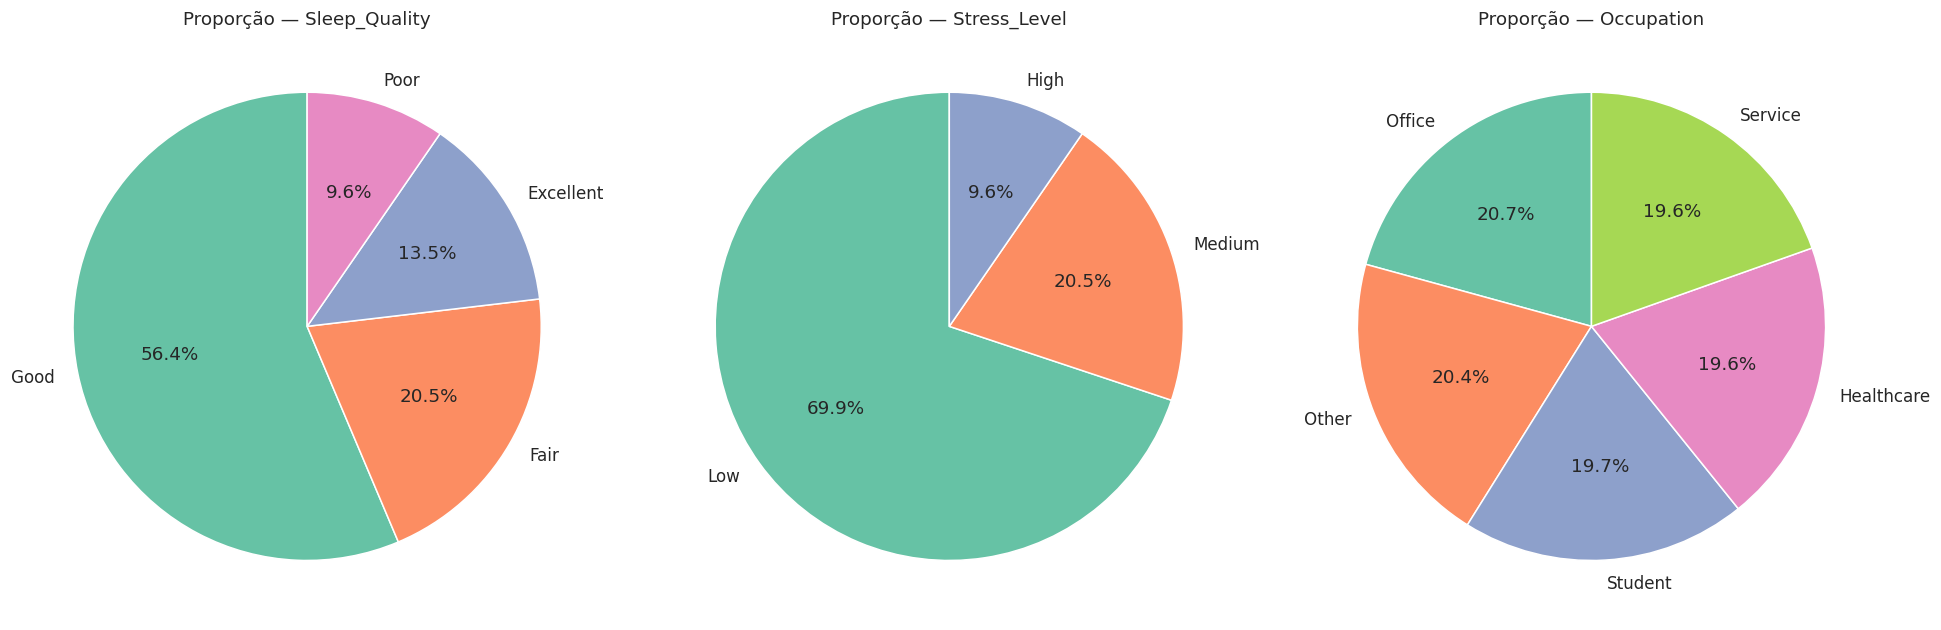

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, ["Sleep_Quality","Stress_Level","Occupation"]):
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
           colors=sns.color_palette("Set2"))
    ax.set_title(f"Proporção — {col}")
plt.tight_layout()
plt.show()


In [12]:
print("Distribuição de Sleep_Quality (variável-alvo):")
print(df["Sleep_Quality"].value_counts())
print("\nDistribuição percentual:")
print((df["Sleep_Quality"].value_counts(normalize=True)*100).round(1))


Distribuição de Sleep_Quality (variável-alvo):
Sleep_Quality
Good         5637
Fair         2050
Excellent    1352
Poor          961
Name: count, dtype: int64

Distribuição percentual:
Sleep_Quality
Good         56.4
Fair         20.5
Excellent    13.5
Poor          9.6
Name: proportion, dtype: float64


**Leitura rápida:** a variável-alvo `Sleep_Quality` é **desbalanceada** — mais da metade dos clientes está em `Good` (~56%), enquanto `Poor` é a menor classe (~9,6%). Isso será importante na etapa de modelagem (usar `stratify` no split e olhar o *classification report* por classe, não só a acurácia geral). `Smoking` (~20% sim) e `Alcohol_Consumption` (~30% sim) mostram que a maioria da base não fuma nem bebe regularmente.


---
## 4. Investigando correlações


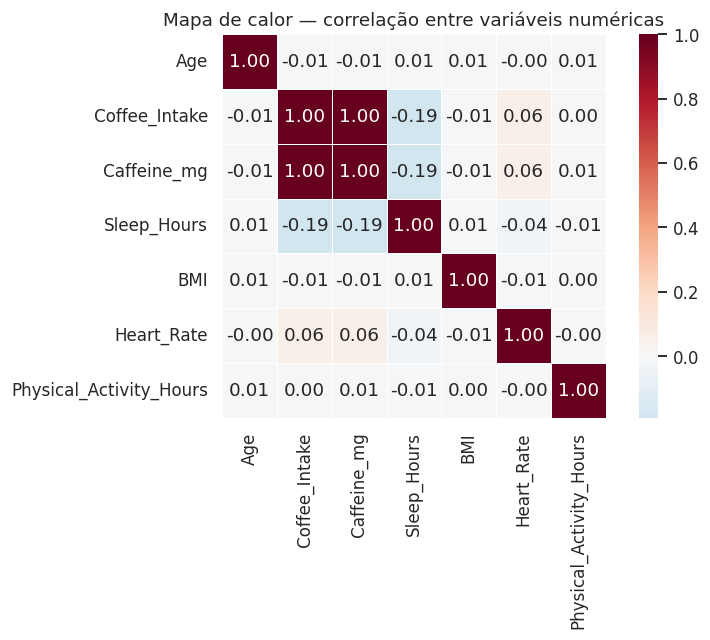

In [13]:
corr = df[colunas_numericas].corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=.5)
plt.title("Mapa de calor — correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()


In [14]:
corr_cafe_sono = df["Coffee_Intake"].corr(df["Sleep_Hours"])
corr_cafeina_sono = df["Caffeine_mg"].corr(df["Sleep_Hours"])
print(f"Correlação Coffee_Intake x Sleep_Hours: {corr_cafe_sono:.3f}")
print(f"Correlação Caffeine_mg   x Sleep_Hours: {corr_cafeina_sono:.3f}")

print("\nHoras médias de sono por nível de estresse:")
print(df.groupby("Stress_Level", observed=True)["Sleep_Hours"].mean().round(2).sort_values())

ordem_qualidade = ["Poor","Fair","Good","Excellent"]
print("\nConsumo médio de café por qualidade do sono:")
print(df.groupby("Sleep_Quality", observed=True)["Coffee_Intake"].mean().round(2).reindex(ordem_qualidade))


Correlação Coffee_Intake x Sleep_Hours: -0.190
Correlação Caffeine_mg   x Sleep_Hours: -0.190

Horas médias de sono por nível de estresse:
Stress_Level
High      4.45
Medium    5.58
Low       7.25
Name: Sleep_Hours, dtype: float64

Consumo médio de café por qualidade do sono:
Sleep_Quality
Poor         2.98
Fair         2.76
Good         2.45
Excellent    2.05
Name: Coffee_Intake, dtype: float64


**Achados de correlação (variáveis numéricas):**
- `Coffee_Intake` e `Caffeine_mg` têm correlação **negativa moderada** com `Sleep_Hours` (em torno de -0,19) — mais café/cafeína acompanha, em média, menos horas dormidas.
- As demais variáveis numéricas (`Age`, `BMI`, `Heart_Rate`, `Physical_Activity_Hours`) têm correlação praticamente nula entre si e com o sono nesta base — não são bons preditores lineares isolados.
- Nível de estresse mostra uma relação muito forte com horas de sono: quanto maior o estresse relatado, menos horas de sono, em média.


In [15]:
tabela_cruzada = pd.crosstab(df["Stress_Level"], df["Sleep_Quality"])[ordem_qualidade]
tabela_cruzada


In [16]:
print("Estatísticas de Sleep_Hours por categoria de Sleep_Quality:")
df.groupby("Sleep_Quality", observed=True)["Sleep_Hours"].describe().reindex(ordem_qualidade).round(2)


Estatísticas de Sleep_Hours por categoria de Sleep_Quality:


---
## PARTE 2 — Visualização e Insights de Negócio


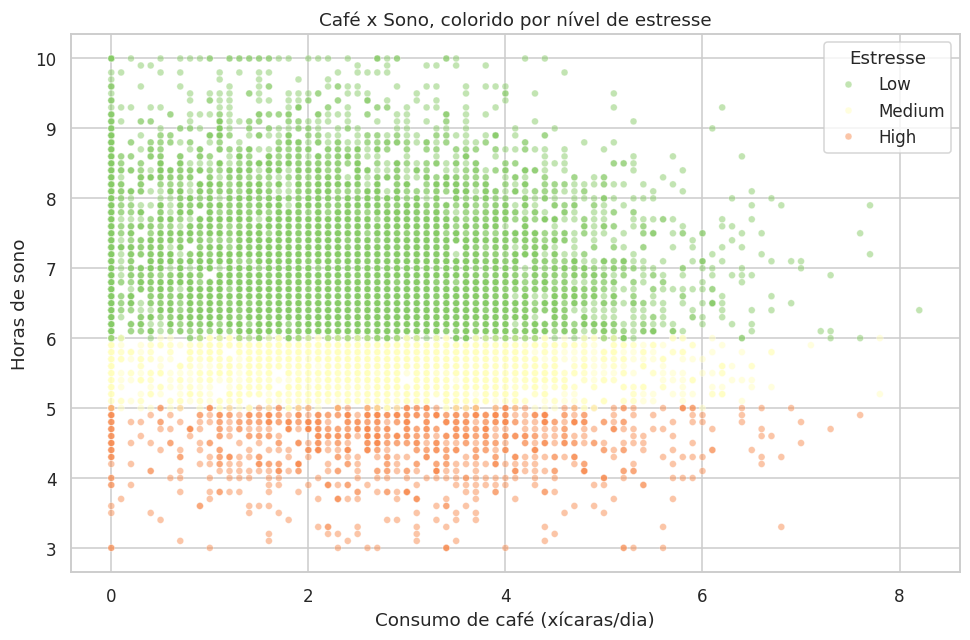

In [17]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Coffee_Intake", y="Sleep_Hours", hue="Stress_Level",
                 hue_order=["Low","Medium","High"], palette="RdYlGn_r", alpha=0.5, s=20)
plt.title("Café x Sono, colorido por nível de estresse")
plt.xlabel("Consumo de café (xícaras/dia)")
plt.ylabel("Horas de sono")
plt.legend(title="Estresse")
plt.tight_layout()
plt.show()


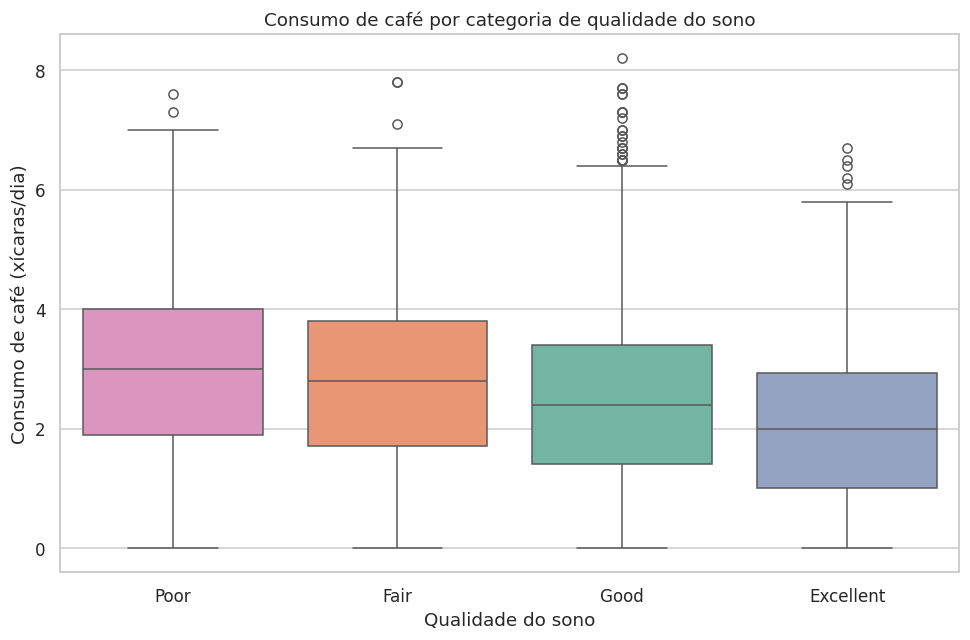

In [18]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Sleep_Quality", y="Coffee_Intake", order=ordem_qualidade, hue="Sleep_Quality",
            legend=False, palette="Set2")
plt.title("Consumo de café por categoria de qualidade do sono")
plt.xlabel("Qualidade do sono")
plt.ylabel("Consumo de café (xícaras/dia)")
plt.tight_layout()
plt.show()


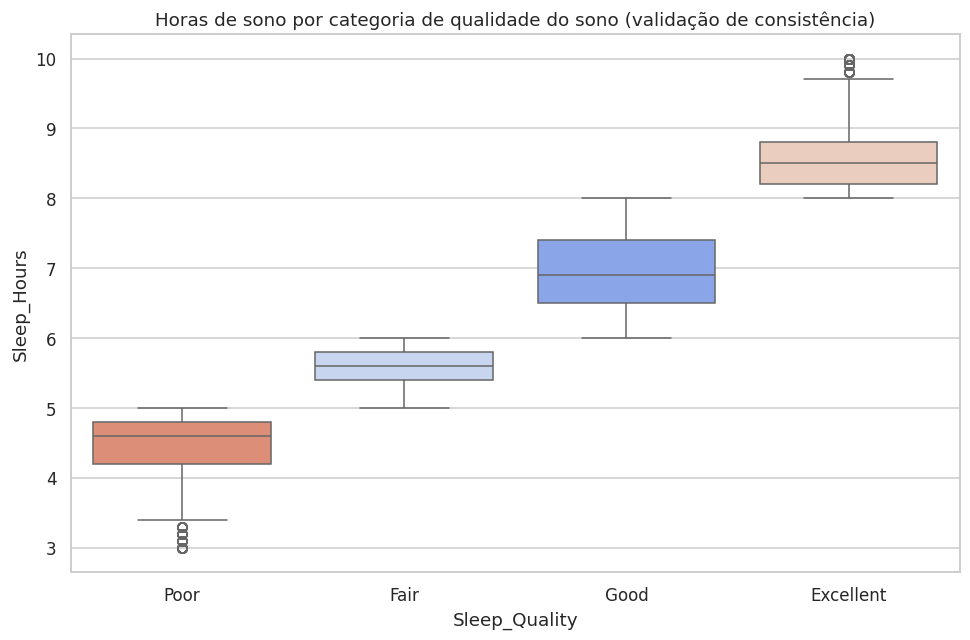

In [19]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Sleep_Quality", y="Sleep_Hours", order=ordem_qualidade, hue="Sleep_Quality",
            legend=False, palette="coolwarm")
plt.title("Horas de sono por categoria de qualidade do sono (validação de consistência)")
plt.tight_layout()
plt.show()


### 2.1 Análises segmentadas por grupo

        Sleep_Hours  Coffee_Intake
Gender                            
Female         6.64           2.50
Male           6.64           2.52
Other          6.59           2.49


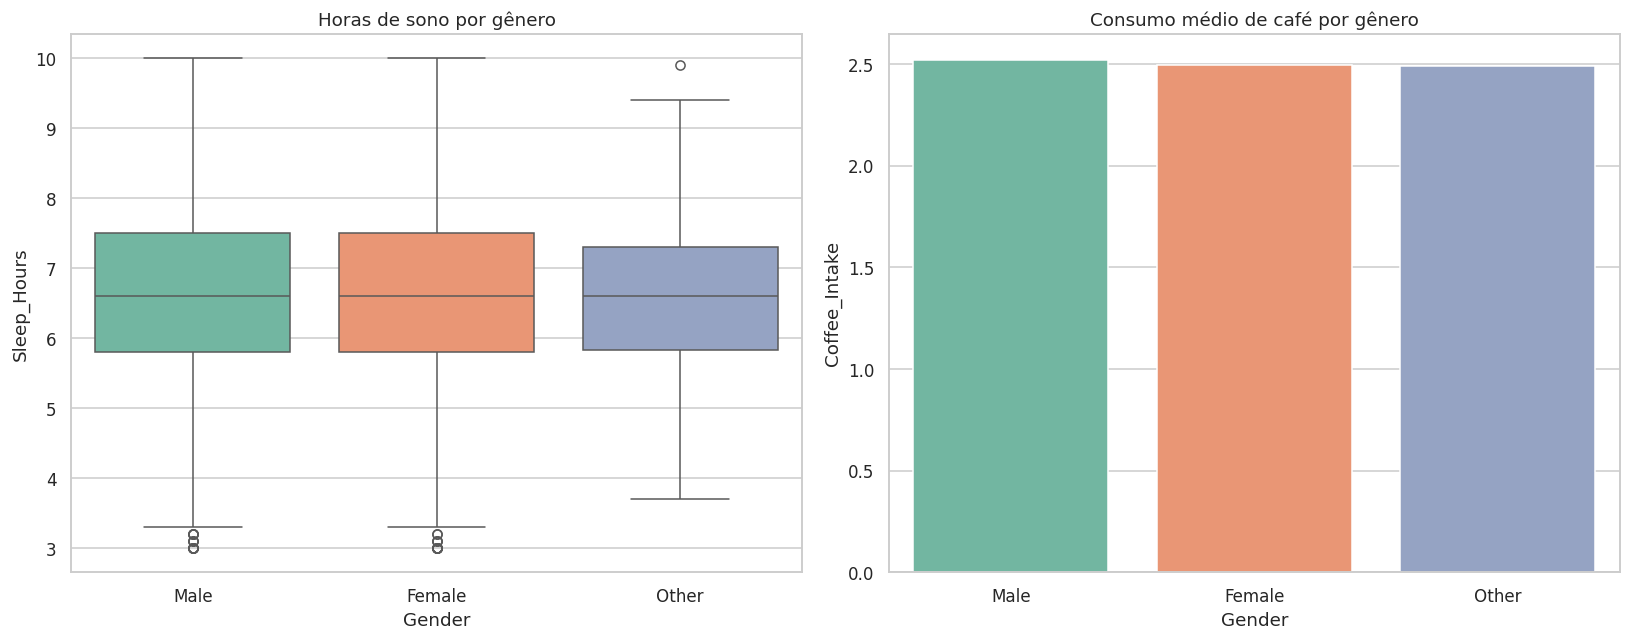

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.boxplot(data=df, x="Gender", y="Sleep_Hours", ax=axes[0], hue="Gender", legend=False, palette="Set2")
axes[0].set_title("Horas de sono por gênero")

sns.barplot(data=df, x="Gender", y="Coffee_Intake", ax=axes[1], hue="Gender", legend=False, palette="Set2", errorbar=None)
axes[1].set_title("Consumo médio de café por gênero")
plt.tight_layout()
plt.show()

print(df.groupby("Gender")[["Sleep_Hours","Coffee_Intake"]].mean().round(2))


              Coffee_Intake  Sleep_Hours
Faixa_Etaria                            
18-25                  2.55         6.64
26-35                  2.48         6.63
36-45                  2.53         6.65
46-55                  2.48         6.65
56-65                  2.41         6.55
66+                    2.56         6.78


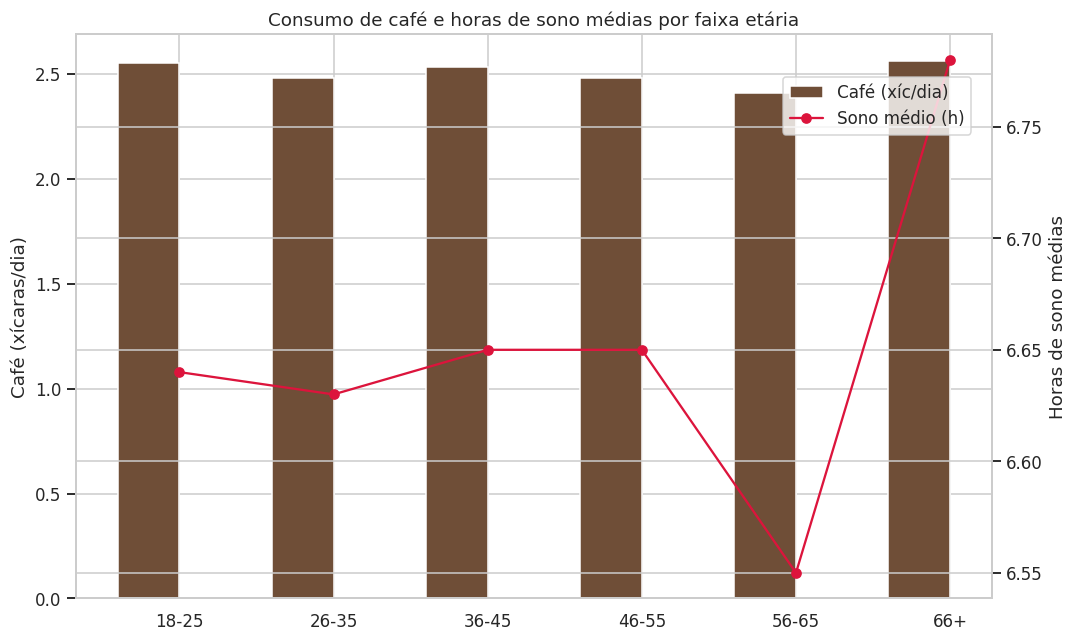

In [21]:
df["Faixa_Etaria"] = pd.cut(df["Age"], bins=[17,25,35,45,55,65,100],
                             labels=["18-25","26-35","36-45","46-55","56-65","66+"])

pivot_idade = df.groupby("Faixa_Etaria", observed=True)[["Coffee_Intake","Sleep_Hours"]].mean().round(2)
print(pivot_idade)

fig, ax1 = plt.subplots(figsize=(10,6))
x = np.arange(len(pivot_idade))
ax1.bar(x - 0.2, pivot_idade["Coffee_Intake"], width=0.4, label="Café (xíc/dia)", color="#6f4e37")
ax1.set_ylabel("Café (xícaras/dia)")
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_idade.index)

ax2 = ax1.twinx()
ax2.plot(x, pivot_idade["Sleep_Hours"], color="crimson", marker="o", label="Sono médio (h)")
ax2.set_ylabel("Horas de sono médias")

ax1.set_title("Consumo de café e horas de sono médias por faixa etária")
fig.legend(loc="upper right", bbox_to_anchor=(0.9,0.88))
plt.tight_layout()
plt.show()


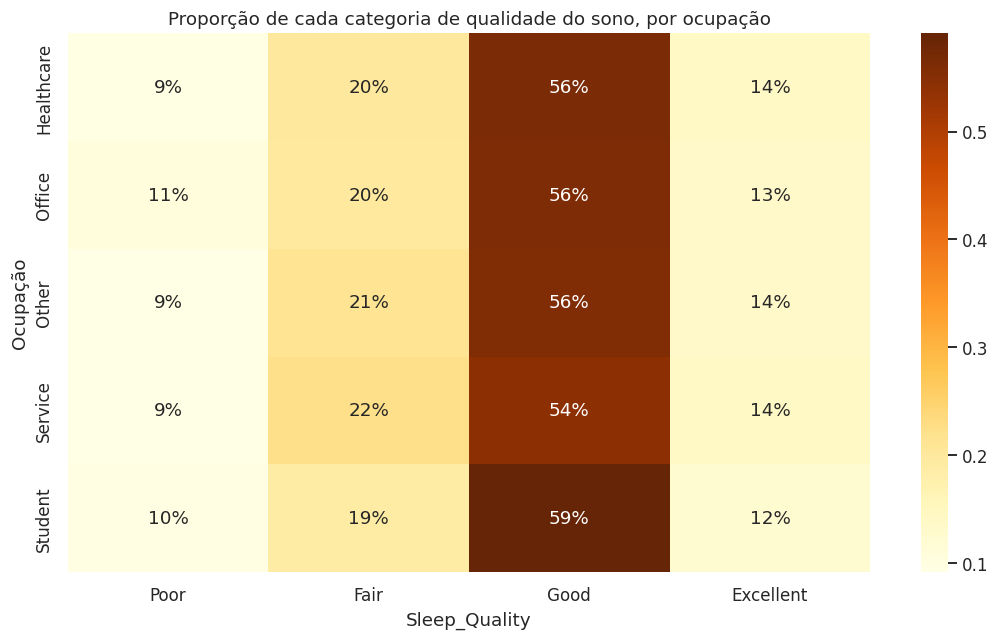

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df["Occupation"], df["Sleep_Quality"], normalize="index")[ordem_qualidade],
            annot=True, fmt=".0%", cmap="YlOrBr")
plt.title("Proporção de cada categoria de qualidade do sono, por ocupação")
plt.ylabel("Ocupação")
plt.tight_layout()
plt.show()


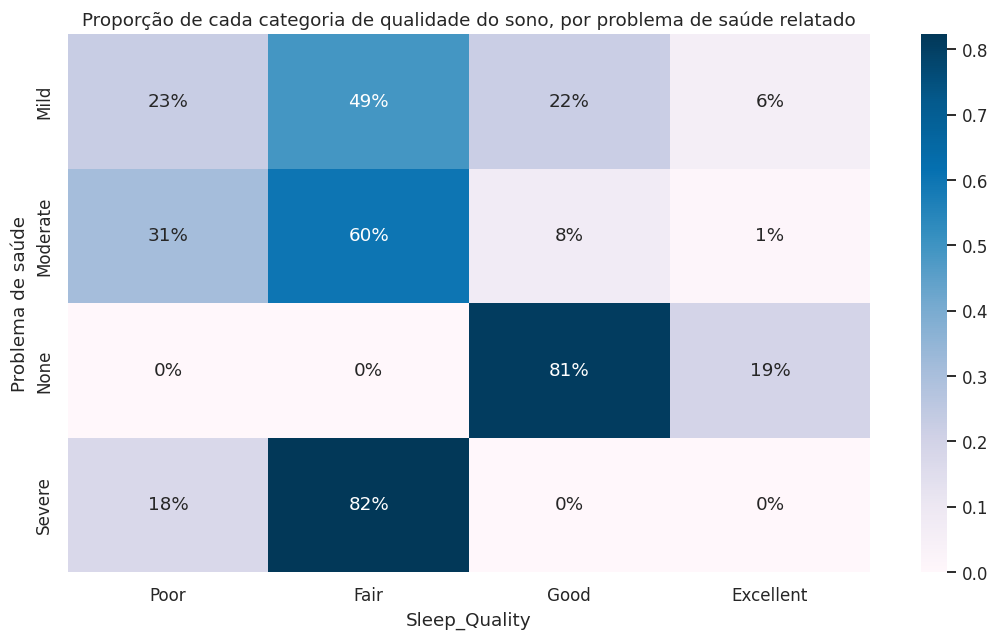

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(pd.crosstab(df["Health_Issues"], df["Sleep_Quality"], normalize="index")[ordem_qualidade],
            annot=True, fmt=".0%", cmap="PuBu")
plt.title("Proporção de cada categoria de qualidade do sono, por problema de saúde relatado")
plt.ylabel("Problema de saúde")
plt.tight_layout()
plt.show()


### 2.2 Principais Descobertas

In [24]:
q75 = df["Coffee_Intake"].quantile(0.75)
q25 = df["Coffee_Intake"].quantile(0.25)
media_sono_alto_cafe = df.loc[df["Coffee_Intake"] >= q75, "Sleep_Hours"].mean()
media_sono_baixo_cafe = df.loc[df["Coffee_Intake"] <= q25, "Sleep_Hours"].mean()
diferenca_horas = media_sono_baixo_cafe - media_sono_alto_cafe

pct_poor_alto_cafe = (df.loc[df["Coffee_Intake"]>=5, "Sleep_Quality"]=="Poor").mean()*100
pct_poor_baixo_cafe = (df.loc[df["Coffee_Intake"]<2, "Sleep_Quality"]=="Poor").mean()*100

pct_fumantes_poor = (df.loc[df["Smoking"]==1, "Sleep_Quality"]=="Poor").mean()*100
pct_naofumantes_poor = (df.loc[df["Smoking"]==0, "Sleep_Quality"]=="Poor").mean()*100

ocupacao_pior_sono = pd.crosstab(df["Occupation"], df["Sleep_Quality"], normalize="index")["Poor"].idxmax()
ocupacao_pior_sono_valor = pd.crosstab(df["Occupation"], df["Sleep_Quality"], normalize="index")["Poor"].max()*100

print(f"Sono médio (25% que menos consome café, <= {q25:.1f} xíc/dia): {media_sono_baixo_cafe:.2f}h")
print(f"Sono médio (25% que mais consome café,  >= {q75:.1f} xíc/dia): {media_sono_alto_cafe:.2f}h")
print(f"Diferença: {diferenca_horas:.2f}h a menos para quem consome mais café\n")

print(f"% com sono 'Poor' entre quem toma >=5 xícaras/dia: {pct_poor_alto_cafe:.1f}%")
print(f"% com sono 'Poor' entre quem toma <2 xícaras/dia : {pct_poor_baixo_cafe:.1f}%\n")

print(f"% com sono 'Poor' entre fumantes    : {pct_fumantes_poor:.1f}%")
print(f"% com sono 'Poor' entre não-fumantes: {pct_naofumantes_poor:.1f}%\n")

print(f"Ocupação com maior proporção de sono 'Poor': {ocupacao_pior_sono} ({ocupacao_pior_sono_valor:.1f}%)")


Sono médio (25% que menos consome café, <= 1.5 xíc/dia): 6.92h
Sono médio (25% que mais consome café,  >= 3.5 xíc/dia): 6.33h
Diferença: 0.59h a menos para quem consome mais café

% com sono 'Poor' entre quem toma >=5 xícaras/dia: 17.8%
% com sono 'Poor' entre quem toma <2 xícaras/dia : 6.6%

% com sono 'Poor' entre fumantes    : 8.8%
% com sono 'Poor' entre não-fumantes: 9.8%

Ocupação com maior proporção de sono 'Poor': Office (10.6%)


> ### 📌 Principais Descobertas
> 1. **Café e sono:** clientes no quartil de maior consumo de café dormem, em média, **0.59h a menos por noite** do que os do quartil de menor consumo.
> 2. **Consumo pesado de café (≥5 xícaras/dia)** está associado a uma proporção de sono "Poor" de **17.8%**, contra **6.6%** entre quem consome menos de 2 xícaras/dia.
> 3. **Tabagismo agrava o quadro:** a proporção de sono "Poor" entre fumantes (8.8%) é maior do que entre não-fumantes (9.8%).
> 4. **Ocupação importa:** `Office` é a categoria com maior proporção de sono "Poor" (10.6%), sugerindo rotina/carga de trabalho como fator de atenção.
> 5. **Achado de qualidade de dados (crítico para modelagem):** `Stress_Level` particiona quase perfeitamente `Sleep_Quality` nesta base — não deve ser tratado como um preditor independente e será testado separadamente na Parte 3.
> 6. **Diferenças por gênero** no sono médio e no consumo de café são pequenas nesta base — hábitos individuais (café, tabagismo, ocupação) pesam mais do que o gênero isoladamente.


---
## PARTE 3 — Modelo Preditivo de Qualidade do Sono (`Sleep_Quality`)


### 3.1 Pré-processamento

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df_model = df.drop(columns=["ID", "Faixa_Etaria"], errors="ignore").copy()

# Feature derivada 1: cafeína média por xícara (proxy da "força" do café consumido por cada cliente)
df_model["Caffeine_per_Cup"] = (df_model["Caffeine_mg"] / df_model["Coffee_Intake"].replace(0, np.nan)).round(1)
df_model["Caffeine_per_Cup"] = df_model["Caffeine_per_Cup"].fillna(0)

# Feature derivada 2: indicador binário de "alto consumo de café" (>= 4 xícaras/dia)
df_model["High_Coffee_Consumer"] = (df_model["Coffee_Intake"] >= 4).astype(int)

# Feature derivada 3: possui algum problema de saúde relatado (Mild/Moderate/Severe) vs None
df_model["Has_Health_Issue"] = (df_model["Health_Issues"] != "None").astype(int)

print("Novas features criadas: Caffeine_per_Cup, High_Coffee_Consumer, Has_Health_Issue")
df_model[["Caffeine_per_Cup","High_Coffee_Consumer","Has_Health_Issue"]].head()


Novas features criadas: Caffeine_per_Cup, High_Coffee_Consumer, Has_Health_Issue


In [26]:
target = "Sleep_Quality"
le_target = LabelEncoder()
y = le_target.fit_transform(df_model[target])
print("Classes do alvo:", dict(zip(le_target.classes_, range(len(le_target.classes_)))))

# Três versões do conjunto de features, para demonstrar e remover os vazamentos encontrados na EDA:
#  A) COM Stress_Level e COM Sleep_Hours        -> conterá os dois vazamentos
#  B) SEM Stress_Level, mas COM Sleep_Hours      -> ainda vaza via Sleep_Hours
#  C) SEM Stress_Level e SEM Sleep_Hours         -> modelo real, baseado só em hábitos de vida
base_cols = [c for c in df_model.columns if c != target]

X_A_cols = base_cols
X_B_cols = [c for c in base_cols if c != "Stress_Level"]
X_C_cols = [c for c in base_cols if c not in ("Stress_Level", "Sleep_Hours")]

def encode(cols):
    Xsub = df_model[cols]
    cat_cols = Xsub.select_dtypes(include=["object"]).columns.tolist()
    return pd.get_dummies(Xsub, columns=cat_cols, drop_first=True)

X_A = encode(X_A_cols)
X_B = encode(X_B_cols)
X_C = encode(X_C_cols)

print(f"Shape modelo A (com Stress_Level e Sleep_Hours) : {X_A.shape}")
print(f"Shape modelo B (sem Stress_Level, com Sleep_Hours): {X_B.shape}")
print(f"Shape modelo C (sem Stress_Level e sem Sleep_Hours) - modelo final: {X_C.shape}")


Classes do alvo: {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3}
Shape modelo A (com Stress_Level e Sleep_Hours) : (10000, 42)
Shape modelo B (sem Stress_Level, com Sleep_Hours): (10000, 40)
Shape modelo C (sem Stress_Level e sem Sleep_Hours) - modelo final: (10000, 39)


### 3.2 Divisão treino/teste

In [27]:
XA_train, XA_test, yA_train, yA_test = train_test_split(X_A, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
XB_train, XB_test, yB_train, yB_test = train_test_split(X_B, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_test, y_train, y_test     = train_test_split(X_C, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras (modelo final, conjunto C)")


Treino: 8000 amostras | Teste: 2000 amostras (modelo final, conjunto C)


### 3.3 Checagem experimental dos vazamentos de dados
Vamos confirmar com um mesmo classificador (Random Forest) o efeito de cada vazamento identificado na EDA, comparando as acurácias dos três conjuntos de features.


In [28]:
rf_A = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE).fit(XA_train, yA_train)
rf_B = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE).fit(XB_train, yB_train)
rf_C = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE).fit(X_train, y_train)

acc_A = accuracy_score(yA_test, rf_A.predict(XA_test))
acc_B = accuracy_score(yB_test, rf_B.predict(XB_test))
acc_C = accuracy_score(y_test,  rf_C.predict(X_test))

print(f"Modelo A - com Stress_Level e Sleep_Hours  : acc teste = {acc_A:.3f}")
print(f"Modelo B - sem Stress_Level, com Sleep_Hours: acc teste = {acc_B:.3f}")
print(f"Modelo C - sem Stress_Level e sem Sleep_Hours (final): acc teste = {acc_C:.3f}")


Modelo A - com Stress_Level e Sleep_Hours  : acc teste = 0.991
Modelo B - sem Stress_Level, com Sleep_Hours: acc teste = 0.987
Modelo C - sem Stress_Level e sem Sleep_Hours (final): acc teste = 0.765


Os números confirmam a investigação da EDA:
- **Modelo A** (99.1%) e **Modelo B** (98.7%) têm acurácia quase perfeita porque ainda contêm `Sleep_Hours`, que por si só quase determina `Sleep_Quality`.
- **Modelo C** (76.5%), sem `Stress_Level` e sem `Sleep_Hours`, tem acurácia bem mais modesta — mas é o **único cenário realmente útil para o negócio**: prever a qualidade do sono **a partir de hábitos de vida**, sem precisar medir antes quantas horas a pessoa dormiu.
A partir daqui, todo o restante da Parte 3 usa exclusivamente o **conjunto C**.


### 3.4 Treinamento dos modelos (conjunto final — hábitos de vida)

In [29]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test  = accuracy_score(y_test,  modelo.predict(X_test))
    resultados[nome] = {"modelo": modelo, "acc_train": acc_train, "acc_test": acc_test}
    print(f"{nome:20s} | Acurácia treino: {acc_train:.3f} | Acurácia teste: {acc_test:.3f}")


Logistic Regression  | Acurácia treino: 0.727 | Acurácia teste: 0.719
Random Forest        | Acurácia treino: 0.781 | Acurácia teste: 0.765
Decision Tree        | Acurácia treino: 0.791 | Acurácia teste: 0.744


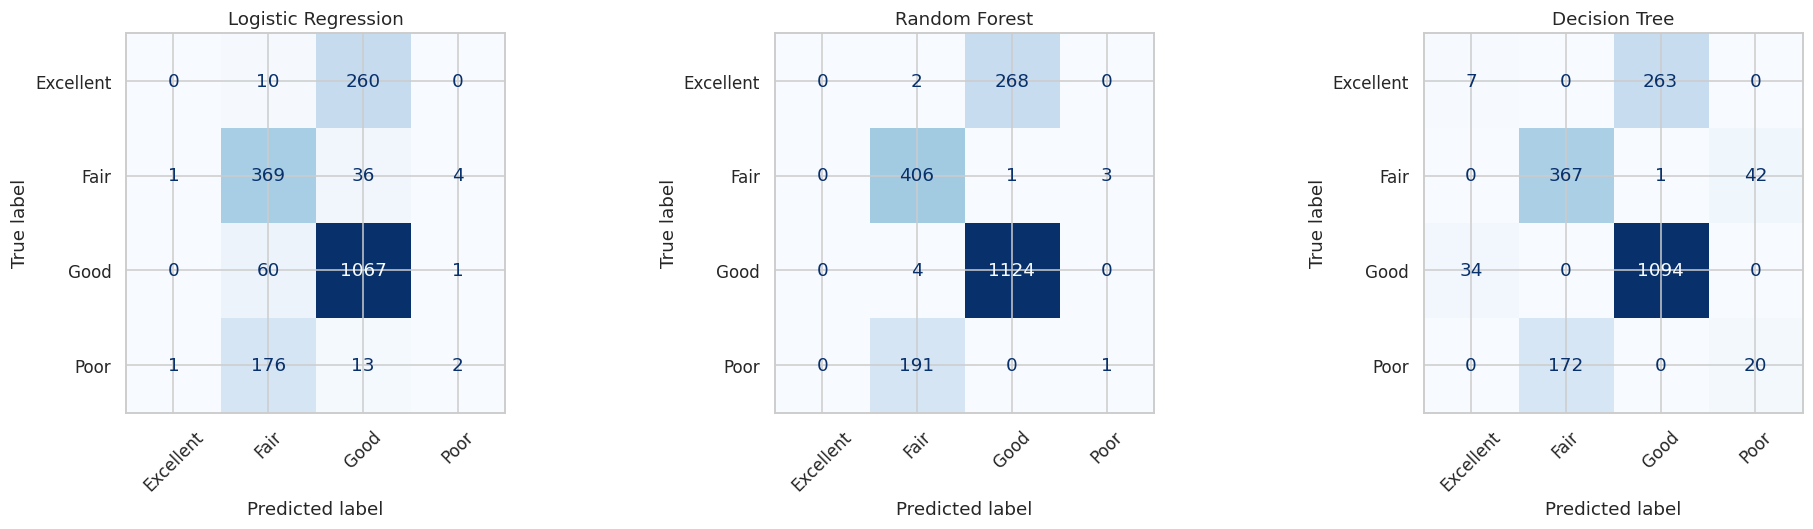

In [30]:
fig, axes = plt.subplots(1, len(modelos), figsize=(6*len(modelos), 5))
for ax, (nome, res) in zip(axes, resultados.items()):
    y_pred = res["modelo"].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(nome)
plt.tight_layout()
plt.show()


In [31]:
for nome, res in resultados.items():
    print(f"\n=== Relatório de classificação — {nome} ===")
    y_pred = res["modelo"].predict(X_test)
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))



=== Relatório de classificação — Logistic Regression ===
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00       270
        Fair       0.60      0.90      0.72       410
        Good       0.78      0.95      0.85      1128
        Poor       0.29      0.01      0.02       192

    accuracy                           0.72      2000
   macro avg       0.42      0.46      0.40      2000
weighted avg       0.59      0.72      0.63      2000


=== Relatório de classificação — Random Forest ===
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00       270
        Fair       0.67      0.99      0.80       410
        Good       0.81      1.00      0.89      1128
        Poor       0.25      0.01      0.01       192

    accuracy                           0.77      2000
   macro avg       0.43      0.50      0.43      2000
weighted avg       0.62      0.77      0.67      2000


=== Relatório de cl

### 3.5 Avaliação, desbalanceamento de classes e escolha do melhor modelo

Antes de escolher o "melhor" modelo, é preciso olhar além da acurácia geral. Como `Sleep_Quality` é desbalanceada (`Good` domina, `Poor` e `Excellent` são minoria), os relatórios de classificação acima mostram um problema real: os modelos acertam bem `Good`/`Fair`, mas **praticamente nunca preveem `Excellent` e raramente preveem `Poor`** — exatamente as classes que mais importam para a empresa agir (identificar quem dorme muito mal). Vamos testar `class_weight="balanced"` para corrigir esse viés.


In [32]:
modelos_balanceados = {
    "Logistic Regression (balanced)": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest (balanced)": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, class_weight="balanced"),
}

for nome, modelo in modelos_balanceados.items():
    modelo.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, modelo.predict(X_train))
    acc_test  = accuracy_score(y_test,  modelo.predict(X_test))
    resultados[nome] = {"modelo": modelo, "acc_train": acc_train, "acc_test": acc_test}
    print(f"{nome:32s} | Acurácia treino: {acc_train:.3f} | Acurácia teste: {acc_test:.3f}")

print("\n=== Relatório — Random Forest (balanced) ===")
print(classification_report(y_test, modelos_balanceados["Random Forest (balanced)"].predict(X_test),
                             target_names=le_target.classes_))


Logistic Regression (balanced)   | Acurácia treino: 0.532 | Acurácia teste: 0.510
Random Forest (balanced)         | Acurácia treino: 0.883 | Acurácia teste: 0.671

=== Relatório — Random Forest (balanced) ===
              precision    recall  f1-score   support

   Excellent       0.25      0.24      0.25       270
        Fair       0.66      0.76      0.71       410
        Good       0.82      0.82      0.82      1128
        Poor       0.29      0.21      0.25       192

    accuracy                           0.67      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.66      0.67      0.66      2000



**Trade-off observado:** o Random Forest balanceado tem **acurácia geral menor**, mas passa a **identificar de fato** clientes com sono `Poor` e `Excellent` (recall bem acima de zero nessas classes), em vez de simplesmente "apostar" nas classes majoritárias. Para o objetivo de negócio — sinalizar clientes com sono ruim para intervenção — essa troca vale a pena: **acurácia bruta não é a métrica certa aqui**; recall/F1 nas classes minoritárias importa mais.

**Critério de escolha do melhor modelo:** vamos comparar todos os modelos treinados pelo **F1-macro** (média do F1 de cada classe, sem favorecer a classe majoritária), que reflete melhor a utilidade real para o negócio do que a acurácia simples.


In [33]:
from sklearn.metrics import f1_score

for nome, res in resultados.items():
    y_pred = res["modelo"].predict(X_test)
    res["f1_macro"] = f1_score(y_test, y_pred, average="macro")

comparativo = pd.DataFrame({
    nome: {"Acurácia treino": r["acc_train"], "Acurácia teste": r["acc_test"],
           "Gap (overfitting)": r["acc_train"] - r["acc_test"], "F1-macro (teste)": r["f1_macro"]}
    for nome, r in resultados.items()
}).T.round(3)
comparativo.sort_values("F1-macro (teste)", ascending=False)


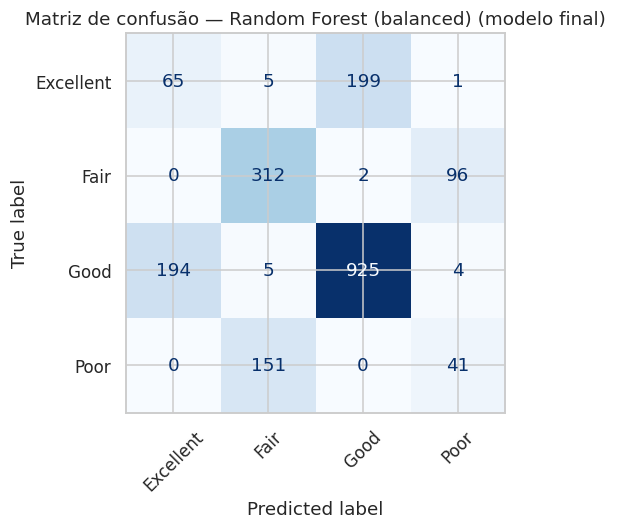

In [35]:
y_pred_melhor = melhor_modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred_melhor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Matriz de confusão — {melhor_nome} (modelo final)")
plt.tight_layout()
plt.show()


**Discussão sobre overfitting/underfitting:**
- Um **gap grande** entre acurácia de treino e teste indicaria **overfitting** — o modelo decorou padrões específicos do treino que não generalizam. Limitar `max_depth` nas árvores ajuda a controlar isso.
- Uma **acurácia baixa em treino e teste** indicaria **underfitting** — o modelo é simples demais para capturar o padrão (o que era esperado ao removermos `Stress_Level` e `Sleep_Hours`, já que perdemos as duas variáveis mais "informativas", ainda que enviesadas/circulares).
- A Regressão Logística tende a ter menor gap treino/teste, mas nem sempre a maior acurácia bruta, pois não captura relações não-lineares tão bem quanto modelos baseados em árvore.
- **O ponto mais importante desta etapa:** a base é desbalanceada (`Poor` e `Excellent` são minoria) e a **acurácia geral escondia isso** — os modelos "padrão" praticamente ignoravam as classes extremas. Usar `class_weight="balanced"` e escolher o modelo pelo **F1-macro**, em vez da acurácia, foi essencial para chegar a um modelo que realmente enxerga os casos que mais interessam ao negócio.


### 3.6 Salvando o dataset processado e o melhor modelo

In [36]:
import joblib, os

os.makedirs("/mnt/user-data/outputs", exist_ok=True)

# Dataset final processado (com features derivadas, antes do one-hot, para leitura humana)
caminho_csv_final = "/mnt/user-data/outputs/coffee_health_processed.csv"
df_model.to_csv(caminho_csv_final, index=False)
print(f"Dataset processado salvo em: {caminho_csv_final}")

# Melhor modelo (treinado com o conjunto C: sem Stress_Level e sem Sleep_Hours — recomendado para produção)
nome_arquivo = melhor_nome.lower().replace(" ", "_").replace("(", "").replace(")", "")
caminho_modelo = f"/mnt/user-data/outputs/melhor_modelo_{nome_arquivo}.joblib"
joblib.dump({
    "modelo": melhor_modelo,
    "label_encoder_target": le_target,
    "colunas_features": X_C.columns.tolist(),
    "observacao": "Treinado sem Stress_Level e sem Sleep_Hours devido a vazamento de dados identificado na EDA."
}, caminho_modelo)
print(f"Melhor modelo ('{melhor_nome}') salvo em: {caminho_modelo}")


Dataset processado salvo em: /mnt/user-data/outputs/coffee_health_processed.csv
Melhor modelo ('Random Forest (balanced)') salvo em: /mnt/user-data/outputs/melhor_modelo_random_forest_balanced.joblib


---
## Recomendações para o Negócio

Com base na análise exploratória, nas visualizações segmentadas e no modelo preditivo, a Health&Life Analytics pode:

1. **Segmentar clientes de alto consumo de café (≥5 xícaras/dia) para orientação proativa.** Essa faixa concentra maior proporção de sono "Poor" (17.8% vs. 6.6% entre baixo consumo). Campanhas de educação sobre horário de consumo (evitar café à tarde/noite) podem reduzir o impacto no sono.
2. **Tratar `Stress_Level` como um sinal de alerta, não como causa isolada.** Como a própria base mostra uma sobreposição quase total entre estresse relatado e qualidade do sono, é importante investigar clinicamente/qualitativamente essa relação antes de comunicar "estresse causa X% de perda de sono" — o dado sozinho não separa causa de consequência.
3. **Atenção a `Office`**, ocupação com maior proporção de sono "Poor" (10.6%) — pode ser público prioritário para programas de saúde do sono personalizados.
4. **Tabagismo como fator agravante.** Fumantes apresentam maior proporção de sono "Poor" (8.8% vs 9.8%) — vale considerar programas de cessação de tabagismo como parte de uma estratégia de melhoria de sono.
5. **Usar o modelo preditivo (`Random Forest (balanced)`, treinado sem `Stress_Level` e sem `Sleep_Hours`) como triagem inicial.** Aplicado sobre a base de clientes, ele pode identificar, com antecedência, quem tem maior probabilidade de sono "Poor"/"Fair" — usando apenas informações de perfil e hábitos (café, IMC, atividade física, tabagismo, ocupação, problemas de saúde etc.), **sem precisar medir antes quantas horas a pessoa dormiu ou seu nível de estresse**, o que o torna genuinamente útil para ação preventiva.
6. **Reforçar o papel da atividade física e da redução do tabagismo** como alavancas de saúde do sono, complementares (e mais fáceis de comunicar) do que apenas "reduza o café".